# PRIS — 01. Data Preprocessing, Feature Engineering & EDA
Placement Readiness Intelligence System — builds the "Feature Builder" numeric features
(the same ones the deployed app computes from Gemini/Groq resume+JD extraction) from the
`student_placement_synthetic.csv` dataset, then explores the data.

**Output:** `student_placement_processed.csv` (used by `02_model_training.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Data Collection

In [2]:
df = pd.read_csv("student_placement_synthetic.csv")
print(df.shape)
df.head()

(100000, 18)


,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  str    
 1   college_tier               100000 non-null  str    
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100000 non-nul

## 2. Data Preprocessing\n- Drop duplicates\n- `salary_package_lpa` is NaN when a student wasn't placed -> fill with 0

In [4]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
df["salary_package_lpa"] = df["salary_package_lpa"].fillna(0.0)
df.isna().sum()

Missing values:
 branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

Duplicate rows: 0


branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64

## 3. Feature Builder
The PRIS spec's Gemini/Groq pipeline extracts structured resume + JD data and converts it
into these numeric features for the ML model. We derive the same 10 features here from the
dataset's academic/skill columns so the model can be trained; `app.py` recomputes the
identical feature set at inference time from the LLM's structured resume/JD output.

In [5]:
TECH_COLS = ["coding_skills", "dsa_score", "ml_knowledge", "system_design"]
CRIT_COLS = ["coding_skills", "dsa_score"]

df["skill_match_percentage"] = df[TECH_COLS].mean(axis=1) / 10 * 100
df["critical_skill_match_percentage"] = df[CRIT_COLS].mean(axis=1) / 10 * 100
df["missing_skills_count"] = (df[TECH_COLS] < 5).sum(axis=1)
df["critical_missing_skills_count"] = (df[CRIT_COLS] < 5).sum(axis=1)
df["project_relevance_score"] = (df["projects_count"] / 5 * 100).clip(0, 100)
df["certification_relevance_score"] = (df["certifications"] / 4 * 100).clip(0, 100)
df["internship_relevance_score"] = (df["internships"] / 3 * 100).clip(0, 100)
df["resume_completeness_score"] = (
    (df["projects_count"] > 0).astype(int)
    + (df["certifications"] > 0).astype(int)
    + (df["internships"] > 0).astype(int)
    + (df["open_source_contributions"] > 0).astype(int)
    + (df["extracurriculars"] > 0).astype(int)
    + (df["hackathons"] > 0).astype(int)
) / 6 * 100
df["keyword_match_score"] = (df["communication_skills"] / 10 * 100 + df["aptitude_score"]) / 2

TIER_MAP = {"Tier-1": 100, "Tier-2": 70, "Tier-3": 45}
df["role_category_match_score"] = df["college_tier"].map(TIER_MAP)

FEATURE_COLS = [
    "skill_match_percentage", "critical_skill_match_percentage",
    "missing_skills_count", "critical_missing_skills_count",
    "project_relevance_score", "certification_relevance_score",
    "internship_relevance_score", "resume_completeness_score",
    "keyword_match_score", "role_category_match_score",
]
df[FEATURE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
skill_match_percentage,100000.0,50.032050,8.823315,13.50,44.00,50.000000,56.000000,84.75
critical_skill_match_percentage,100000.0,57.479290,11.624042,14.50,49.50,57.500000,65.500000,100.00
missing_skills_count,100000.0,1.913510,0.934344,0.00,1.00,2.000000,3.000000,4.00
critical_missing_skills_count,100000.0,0.623190,0.647895,0.00,0.00,1.000000,1.000000,2.00
project_relevance_score,100000.0,47.945600,24.856581,0.00,20.00,40.000000,60.000000,100.00
certification_relevance_score,100000.0,37.496250,27.851755,0.00,25.00,25.000000,50.000000,100.00
internship_relevance_score,100000.0,36.501333,31.342131,0.00,0.00,33.333333,66.666667,100.00
resume_completeness_score,100000.0,66.660667,17.459404,0.00,50.00,66.666667,83.333333,100.00
keyword_match_score,100000.0,62.448326,9.608965,22.55,55.95,62.450000,68.950000,99.40
role_category_match_score,100000.0,63.154900,19.224927,45.00,45.00,70.000000,70.000000,100.00


## 4. Proxy `readiness_label` Target
The raw dataset has no `readiness_label`. We build a reliable proxy target using a weighted
composite of the Feature-Builder scores **plus** CGPA and backlog signals (available in this
dataset but not from a resume), then bucket into 4 balanced classes by quantile. The
classifier itself is only ever trained/served on `FEATURE_COLS` — cgpa/backlogs are used
solely to construct this training label, never as model input.

In [6]:
cgpa_score = (df["cgpa"] - 4) / (10 - 4) * 100
backlog_penalty = (df["backlogs"] * 5).clip(0, 15)

weights = dict(
    skill_match_percentage=0.20, critical_skill_match_percentage=0.15,
    project_relevance_score=0.15, certification_relevance_score=0.10,
    internship_relevance_score=0.10, resume_completeness_score=0.10,
    keyword_match_score=0.05, role_category_match_score=0.05,
)
composite = sum(df[c] * w for c, w in weights.items()) + cgpa_score * 0.10
readiness_score = (composite - backlog_penalty).clip(0, 100)

q25, q50, q75 = readiness_score.quantile([0.25, 0.5, 0.75])
print("Quantile cut points:", q25, q50, q75)

def bucket(s):
    if s <= q25:
        return "Not Ready Yet"
    elif s <= q50:
        return "Needs Improvement"
    elif s <= q75:
        return "Moderately Ready"
    return "Highly Ready"

df["readiness_score_proxy"] = readiness_score
df["readiness_label"] = readiness_score.apply(bucket)
df["readiness_label"].value_counts()

Quantile cut points: 43.08083333333333 49.00083333333333 54.784375000000004


readiness_label
Needs Improvement    25002
Not Ready Yet        25001
Highly Ready         25000
Moderately Ready     24997
Name: count, dtype: int64

## 5. Exploratory Data Analysis

/tmp/ipykernel_541/2647291039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="readiness_label", order=order, palette="viridis")


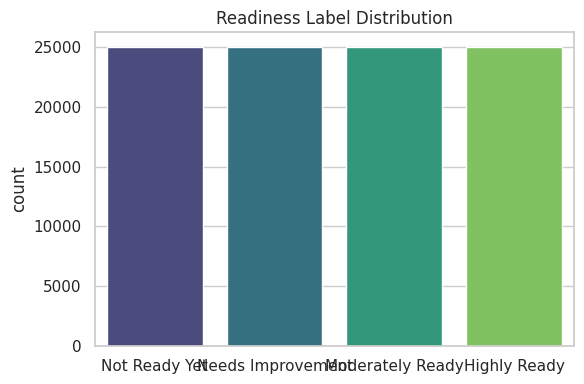

In [ ]:
order = ["Not Ready Yet", "Needs Improvement", "Moderately Ready", "Highly Ready"]
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readiness_label", order=order, palette="viridis")
plt.title("Readiness Label Distribution")
plt.xlabel("")
plt.tight_layout()
plt.show()

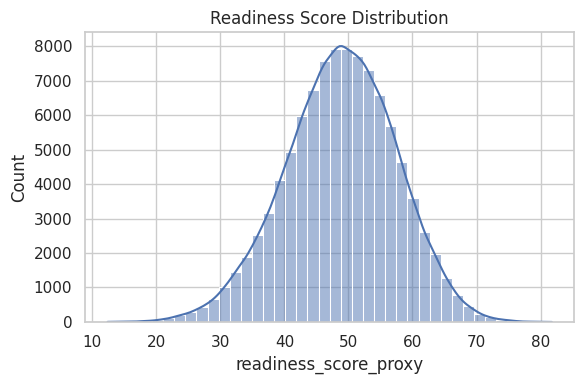

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(df["readiness_score_proxy"], bins=40, kde=True)
plt.title("Readiness Score Distribution")
plt.tight_layout()
plt.show()

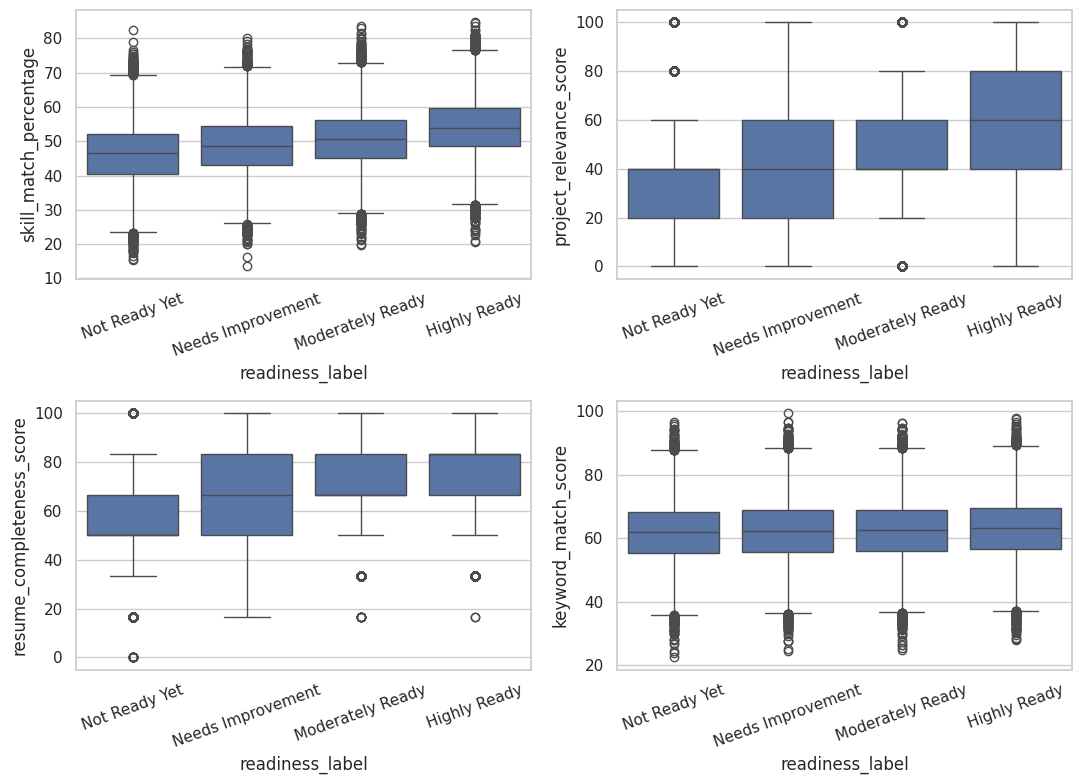

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.boxplot(data=df, x="readiness_label", y="skill_match_percentage", order=order, ax=axes[0, 0])
sns.boxplot(data=df, x="readiness_label", y="project_relevance_score", order=order, ax=axes[0, 1])
sns.boxplot(data=df, x="readiness_label", y="resume_completeness_score", order=order, ax=axes[1, 0])
sns.boxplot(data=df, x="readiness_label", y="keyword_match_score", order=order, ax=axes[1, 1])
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

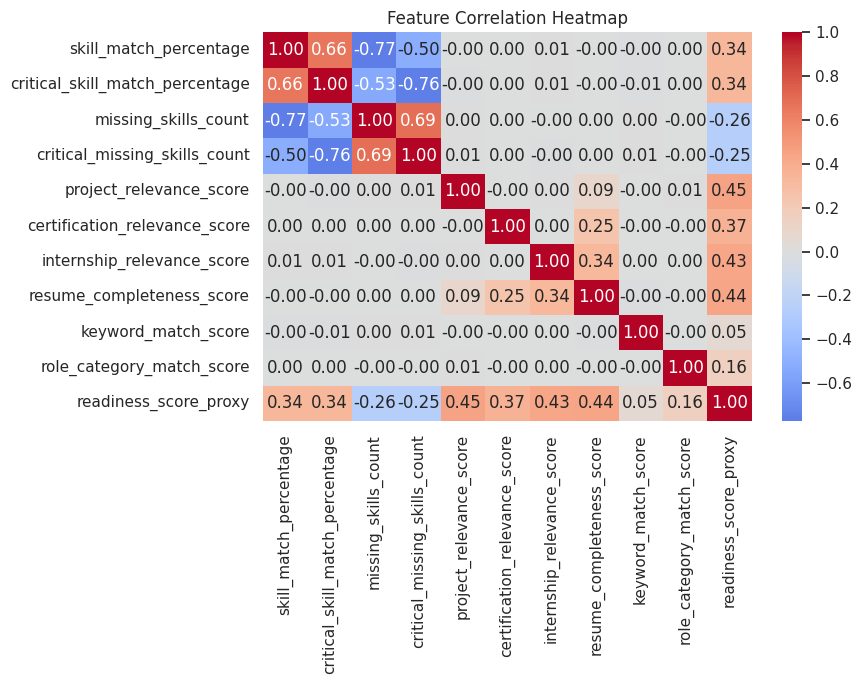

In [10]:
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLS + ["readiness_score_proxy"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

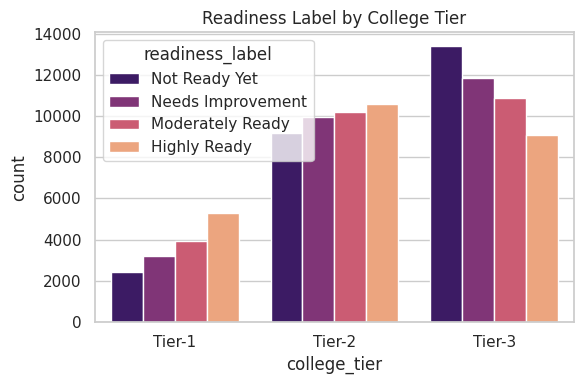

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="college_tier", hue="readiness_label", hue_order=order,
              order=["Tier-1", "Tier-2", "Tier-3"], palette="magma")
plt.title("Readiness Label by College Tier")
plt.tight_layout()
plt.show()

## 6. Save Processed Dataset

In [12]:
df.to_csv("student_placement_processed.csv", index=False)
print("Saved student_placement_processed.csv", df.shape)

Saved student_placement_processed.csv (100000, 30)
